# **CNN**

In [ ]:
!pip install tensorflow-datasets

In [ ]:
import tensorflow  as tf
import matplotlib.pyplot as plt
import numpy as np

In [ ]:
import tensorflow_datasets as tfds

dataset, info = tfds.load(
    "cats_vs_dogs",
    split=["train[:80%]", "train[80%:]"],
    as_supervised=True,
    with_info=True,
    shuffle_files=True,
)

train_data, test_data = dataset

Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Generating splits...:   0%|          | 0/1 [00:00<?, ? splits/s]

Generating train examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/cats_vs_dogs/incomplete.NP5ZY4_4.0.1/cats_vs_dogs-train.tfrecord*...:   0%…

Dataset cats_vs_dogs downloaded and prepared to /root/tensorflow_datasets/cats_vs_dogs/4.0.1. Subsequent calls will reuse this data.


In [ ]:
IMG_SIZE = 224

def preprocess(image, label):
    image = tf.image.resize(image, (IMG_SIZE, IMG_SIZE))
    image = image / 255.0
    return image, label

train_data = train_data.map(preprocess).batch(32)
test_data = test_data.map(preprocess).batch(32)

In [ ]:
for img, label in train_data.take(1):
    print(img.shape)

(32, 224, 224, 3)


In [ ]:
class_names = info.features['label'].names
print(class_names)

['cat', 'dog']


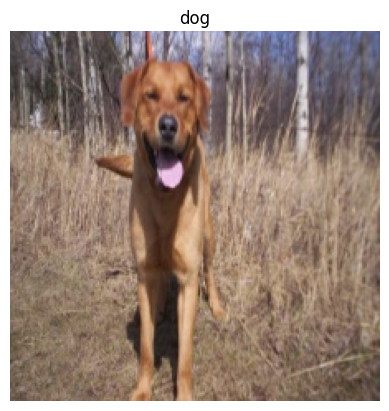

In [ ]:
for images, labels in train_data.take(1):

    img = images[0]
    label = labels[0]

    plt.imshow(img)
    plt.title(class_names[label.numpy()])
    plt.axis("off")
    plt.show()

In [ ]:
#Implementing the data augmentation to prevent the overfitting
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.1),
    tf.keras.layers.RandomZoom(0.1),
])

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models

model = models.Sequential()

model.add(data_augmentation)

# Block 1
model.add(layers.Conv2D(32, (3,3), activation='relu', input_shape=(224,224,3)))
model.add(layers.MaxPooling2D((2,2)))

# Block 2
model.add(layers.Conv2D(64, (3,3), activation='relu'))
model.add(layers.MaxPooling2D((2,2)))

# Block 3
model.add(layers.Conv2D(128, (3,3), activation='relu'))
model.add(layers.MaxPooling2D((2,2)))

# Block 4
model.add(layers.Conv2D(128, (3,3), activation='relu'))
model.add(layers.MaxPooling2D((2,2)))

# Flatten layer
model.add(layers.Flatten())

# Dense layers
model.add(layers.Dense(512, activation='relu'))
model.add(layers.Dropout(0.5))

# Output layer (Binary classification)
model.add(layers.Dense(1, activation='sigmoid'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model.compile(
    optimizer = 'adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [ ]:
history = model.fit(train_data,validation_data=test_data,epochs=50)

Epoch 1/50
582/582 ━━━━━━━━━━━━━━━━━━━━ 41s 70ms/step - accuracy: 0.9013 - loss: 0.2339 - val_accuracy: 0.9106 - val_loss: 0.2268
Epoch 2/50
582/582 ━━━━━━━━━━━━━━━━━━━━ 45s 77ms/step - accuracy: 0.9078 - loss: 0.2227 - val_accuracy: 0.9015 - val_loss: 0.2451
Epoch 3/50
582/582 ━━━━━━━━━━━━━━━━━━━━ 41s 70ms/step - accuracy: 0.9055 - loss: 0.2252 - val_accuracy: 0.9151 - val_loss: 0.2177
Epoch 4/50
582/582 ━━━━━━━━━━━━━━━━━━━━ 41s 70ms/step - accuracy: 0.9081 - loss: 0.2166 - val_accuracy: 0.9046 - val_loss: 0.2297
Epoch 5/50
582/582 ━━━━━━━━━━━━━━━━━━━━ 41s 70ms/step - accuracy: 0.9132 - loss: 0.2134 - val_accuracy: 0.9125 - val_loss: 0.2227
Epoch 6/50
582/582 ━━━━━━━━━━━━━━━━━━━━ 41s 70ms/step - accuracy: 0.9142 - loss: 0.2070 - val_accuracy: 0.9089 - val_loss: 0.2226
Epoch 7/50
582/582 ━━━━━━━━━━━━━━━━━━━━ 42s 72ms/step - accuracy: 0.9155 - loss: 0.2093 - val_accuracy: 0.9089 - val_loss: 0.2364
Epoch 8/50
582/582 ━━━━━━━━━━━━━━━━━━━━ 41s 71ms/step - accuracy: 0.9159 - loss: 0.2064 - 

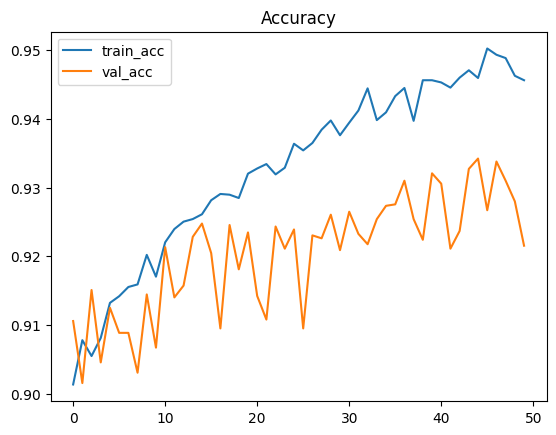

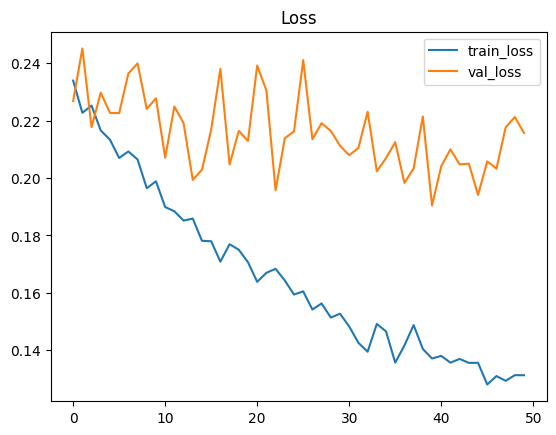

In [ ]:
import matplotlib.pyplot as plt

acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

loss = history.history['loss']
val_loss = history.history['val_loss']

plt.plot(acc,label="train_acc")
plt.plot(val_acc,label="val_acc")
plt.legend()
plt.title("Accuracy")
plt.show()

plt.plot(loss,label="train_loss")
plt.plot(val_loss,label="val_loss")
plt.legend()
plt.title("Loss")
plt.show()

In [ ]:
import numpy as np
from tensorflow.keras.preprocessing import image

In [ ]:
img_path = r"/content/dog1.jpg"

In [ ]:
img = image.load_img(img_path, target_size=(224,224))

In [ ]:
img_array = image.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)
img_array = img_array / 255.0

In [ ]:
prediction = model.predict(img_array)
print(prediction)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
[[0.96211106]]


In [ ]:
if prediction[0][0] > 0.5:
    print("Dog")
else:
    print("Cat")

Dog


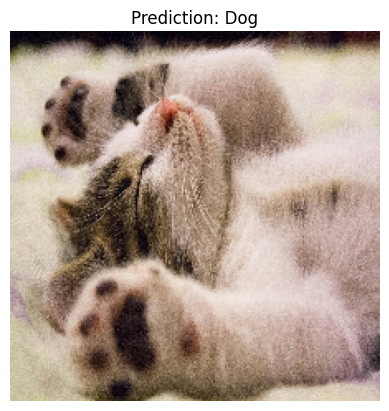

In [ ]:
import matplotlib.pyplot as plt

plt.imshow(img)
plt.title("Prediction: Dog" if prediction[0][0] > 0.5 else "Prediction: Cat")
plt.axis("off")
plt.show()

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os

# Check root of My Drive
print(" Files in MyDrive root:")
print(os.listdir('/content/drive/MyDrive/'))

📁 Files in MyDrive root:
['Colab Notebooks', 'IBM certificate Python Data Analysis.pdf', 'EDUSKILLS Certificaate internship.pdf']


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

# Save to Drive
model.save('/content/drive/MyDrive/history.keras')

# Load from Drive next time
model = load_model('/content/drive/MyDrive/history.keras')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

from tensorflow.keras.models import load_model

# Load the model directly from Google Drive
model = load_model('/content/drive/MyDrive/history.keras')

print("Model loaded successfully!")
model.summary()

Mounted at /content/drive
Model loaded successfully!


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 24, 24, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 12, 12, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 18432)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │     9,437,696 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           513 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 29,037,125 (110.77 MB)

 Trainable params: 9,679,041 (36.92 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 19,358,084 (73.85 MB)

In [ ]:
import numpy as np
from tensorflow.keras.preprocessing import image
from google.colab import files

# Upload image from your PC
uploaded = files.upload()

# Get the uploaded filename
img_name = list(uploaded.keys())[0]

# Preprocess the image
img = image.load_img(img_name, target_size=(224, 224))
img_array = image.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)
img_array = img_array / 255.0

# Make Prediction
prediction = model.predict(img_array)
confidence = prediction[0][0]

print(f"\n🔍 Raw prediction value: {confidence:.4f}")

# Display Result
if confidence > 0.5:
    print(f"🐶 It's a DOG! (confidence: {confidence*100:.2f}%)")
else:
    print(f"🐱 It's a CAT! (confidence: {(1-confidence)*100:.2f}%)")

Saving Screenshot 2026-04-22 223846.png to Screenshot 2026-04-22 223846.png
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step

🔍 Raw prediction value: 0.6721
🐶 It's a DOG! (confidence: 67.21%)
